<a href="https://colab.research.google.com/github/KrzysztofDrobnik/lecture1/blob/Unsupervised-learning/k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import numpy as np

#wczytanie danych
df = pd.read_csv('/content/countries of the world (2).csv')

df.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,"48,0","0,00","23,06","163,07",700.0,"36,0","3,2","12,13","0,22","87,65",1,"46,6","20,34","0,38","0,24","0,38"
1,Albania,EASTERN EUROPE,3581655,28748,"124,6","1,26","-4,93","21,52",4500.0,"86,5","71,2","21,09","4,42","74,49",3,"15,11","5,22","0,232","0,188","0,579"
2,Algeria,NORTHERN AFRICA,32930091,2381740,"13,8","0,04","-0,39",31,6000.0,"70,0","78,1","3,22","0,25","96,53",1,"17,14","4,61","0,101","0,6","0,298"
3,American Samoa,OCEANIA,57794,199,"290,4","58,29","-20,71","9,27",8000.0,"97,0","259,5",10,15,75,2,"22,46","3,27",NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,"152,1","0,00","6,6","4,05",19000.0,"100,0","497,2","2,22",0,"97,78",3,"8,71","6,25",NaN,NaN,NaN


In [44]:
#usunięcie tekstowej kolumny 'Region'
df = df.drop(columns=['Region'])
df.head()

,Country,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,31056997,647500,"48,0","0,00","23,06","163,07",700.0,"36,0","3,2","12,13","0,22","87,65",1,"46,6","20,34","0,38","0,24","0,38"
1,Albania,3581655,28748,"124,6","1,26","-4,93","21,52",4500.0,"86,5","71,2","21,09","4,42","74,49",3,"15,11","5,22","0,232","0,188","0,579"
2,Algeria,32930091,2381740,"13,8","0,04","-0,39",31,6000.0,"70,0","78,1","3,22","0,25","96,53",1,"17,14","4,61","0,101","0,6","0,298"
3,American Samoa,57794,199,"290,4","58,29","-20,71","9,27",8000.0,"97,0","259,5",10,15,75,2,"22,46","3,27",NaN,NaN,NaN
4,Andorra,71201,468,"152,1","0,00","6,6","4,05",19000.0,"100,0","497,2","2,22",0,"97,78",3,"8,71","6,25",NaN,NaN,NaN


In [45]:
#przypisanie danych numerycznych do nowej zmiennej, zamiana przecinków na kropki, konwersja na float, zastąpienie wartości pustych średnią
X = df.drop(columns=['Country'])
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].str.replace(',', '.').astype(float)

for col in X.columns:
  X[col] = X[col].fillna(X[col].mean())
X.head()

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380000,0.240000,0.380000
1,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232000,0.188000,0.579000
2,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101000,0.600000,0.298000
3,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,0.150844,0.282711,0.565283
4,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,0.150844,0.282711,0.565283


In [47]:
#klasteryzacja metodą KMeans, gdzie k = 3
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

df['Cluster'] = kmeans.labels_

In [48]:
df.head()

,Country,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service,Cluster
0,Afghanistan,31056997,647500,"48,0","0,00","23,06","163,07",700.0,"36,0","3,2","12,13","0,22","87,65",1,"46,6","20,34","0,38","0,24","0,38",0
1,Albania,3581655,28748,"124,6","1,26","-4,93","21,52",4500.0,"86,5","71,2","21,09","4,42","74,49",3,"15,11","5,22","0,232","0,188","0,579",0
2,Algeria,32930091,2381740,"13,8","0,04","-0,39",31,6000.0,"70,0","78,1","3,22","0,25","96,53",1,"17,14","4,61","0,101","0,6","0,298",0
3,American Samoa,57794,199,"290,4","58,29","-20,71","9,27",8000.0,"97,0","259,5",10,15,75,2,"22,46","3,27",NaN,NaN,NaN,0
4,Andorra,71201,468,"152,1","0,00","6,6","4,05",19000.0,"100,0","497,2","2,22",0,"97,78",3,"8,71","6,25",NaN,NaN,NaN,0


In [49]:
search_country = "Poland"
result = df[df['Country'].str.strip() == search_country]

In [50]:
result

,Country,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service,Cluster
163,Poland,38536869,312685,"123,3","0,16","-0,49","8,51",11100.0,"99,8","306,3","45,91","1,12","52,97",3,"9,85","9,89","0,05","0,311","0,64",0


In [51]:
df['Cluster'].value_counts()

,count
Cluster,
0,212
2,13
1,2


In [52]:
search_country_claster = result['Cluster']

same_cluster = df[df['Cluster'] == search_country_claster.values[0]]

country_result = same_cluster['Country']

print(f"Countries in the same cluster as {search_country}:")
for country in country_result:
  print(country)

Countries in the same cluster as Poland:
Afghanistan 
Albania 
Algeria 
American Samoa 
Andorra 
Angola 
Anguilla 
Antigua & Barbuda 
Argentina 
Armenia 
Aruba 
Australia 
Austria 
Azerbaijan 
Bahamas, The 
Bahrain 
Barbados 
Belarus 
Belgium 
Belize 
Benin 
Bermuda 
Bhutan 
Bolivia 
Bosnia & Herzegovina 
Botswana 
British Virgin Is. 
Brunei 
Bulgaria 
Burkina Faso 
Burma 
Burundi 
Cambodia 
Cameroon 
Canada 
Cape Verde 
Cayman Islands 
Central African Rep. 
Chad 
Chile 
Colombia 
Comoros 
Congo, Dem. Rep. 
Congo, Repub. of the 
Cook Islands 
Costa Rica 
Cote d'Ivoire 
Croatia 
Cuba 
Cyprus 
Czech Republic 
Denmark 
Djibouti 
Dominica 
Dominican Republic 
East Timor 
Ecuador 
El Salvador 
Equatorial Guinea 
Eritrea 
Estonia 
Ethiopia 
Faroe Islands 
Fiji 
Finland 
France 
French Guiana 
French Polynesia 
Gabon 
Gambia, The 
Gaza Strip 
Georgia 
Ghana 
Gibraltar 
Greece 
Greenland 
Grenada 
Guadeloupe 
Guam 
Guatemala 
Guernsey 
Guinea 
Guinea-Bissau 
Guyana 
Haiti 
Honduras 
Hong Kong 

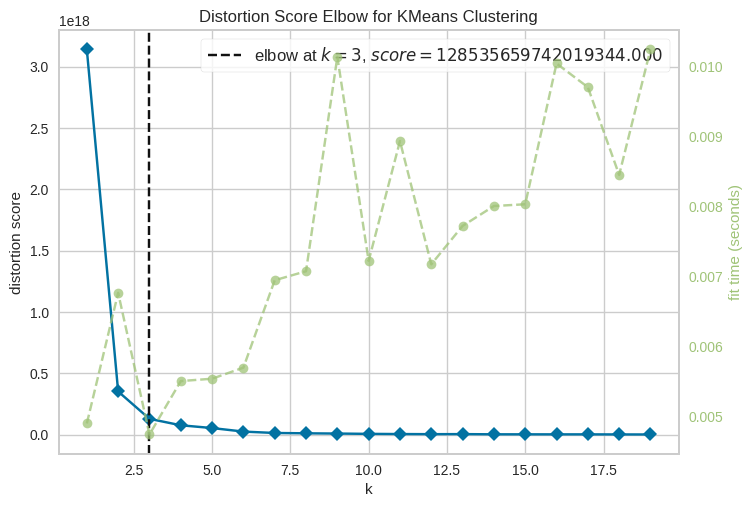

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [57]:
#wizualizacja (Elbow Method)
from yellowbrick.cluster import KElbowVisualizer

method = KMeans()
visualizer = KElbowVisualizer(method, k=(1,20))
visualizer.fit(X)
visualizer.show()

#tyle samo klastrów?

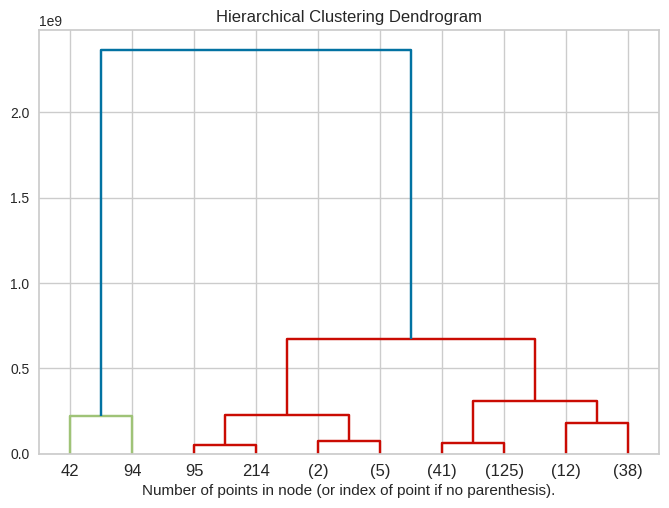

In [58]:
#dendogram
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering

def plot_dendrogram(model, **kwargs):

    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)




model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(X)
plt.title("Hierarchical Clustering Dendrogram")
plot_dendrogram(model, truncate_mode="level", p=3)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()